In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Airbnb_Open_Data.csv")
df.head()

/var/folders/06/r7qgjjbs79zd1tbq326ms76c0000gn/T/ipykernel_6830/1124109820.py:5: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Airbnb_Open_Data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [32]:
df.shape

(102599, 26)

In [33]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [34]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['id', 'name', 'host_id', 'host_identity_verified', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country',
       'country_code', 'instant_bookable', 'cancellation_policy', 'room_type',
       'construction_year', 'price', 'service_fee', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'review_rate_number', 'calculated_host_listings_count',
       'availability_365', 'house_rules', 'license'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   name                            102349 non-null  object 
 2   host_id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host_name                       102193 non-null  object 
 5   neighbourhood_group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country_code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [36]:
df.describe()

,id,host_id,lat,long,construction_year,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [37]:
df.isnull().sum()

id                                     0
name                                 250
host_id                                0
host_identity_verified               289
host_name                            406
neighbourhood_group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country_code                         131
instant_bookable                     105
cancellation_policy                   76
room_type                              0
construction_year                    214
price                                247
service_fee                          273
minimum_nights                       409
number_of_reviews                    183
last_review                        15893
reviews_per_month                  15879
review_rate_number                   326
calculated_host_listings_count       319
availability_365                     448
house_rules     

In [38]:
df['price'].head(10) 

0      $966 
1      $142 
2      $620 
3      $368 
4      $204 
5      $577 
6       $71 
7    $1,060 
8    $1,018 
9      $291 
Name: price, dtype: object

In [ ]:
#Cleaning the price column by removing the dollar sign and commas, converting it to numeric, and filling missing values with the median price.
df['price'] = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['price'] = df['price'].fillna(df['price'].median())
df['price'].head(10) 


0     966.0
1     142.0
2     620.0
3     368.0
4     204.0
5     577.0
6      71.0
7    1060.0
8    1018.0
9     291.0
Name: price, dtype: float64

In [40]:
df['service_fee'] = (
    df['service_fee']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['service_fee'] = pd.to_numeric(df['service_fee'], errors='coerce')
df['service_fee'] = df['service_fee'].fillna(df['service_fee'].median())
df['service_fee'].head(10) 

0    193.0
1     28.0
2    124.0
3     74.0
4     41.0
5    115.0
6     14.0
7    212.0
8    204.0
9     58.0
Name: service_fee, dtype: float64

In [ ]:
#filling missing values in the dataset with appropriate values

df['host_name'] = df['host_name'].fillna("Unknown")
df['host_identity_verified'] = df['host_identity_verified'].fillna("unconfirmed")
df['number_of_reviews'] = df['number_of_reviews'].fillna(0)

#filling missing values in the dataset with median values for numerical columns
df['review_rate_number'] = df['review_rate_number'].fillna(df['review_rate_number'].median())
df['minimum_nights'] = df['minimum_nights'].fillna(df['minimum_nights'].median())
df['calculated_host_listings_count'] = (df['calculated_host_listings_count'].fillna(df['calculated_host_listings_count'].median()))

In [ ]:
#dropping the columns which are not useful for analysis (more than 50% missing values)

df.drop(columns=['license', 'house_rules'], inplace=True)
df.drop(columns=['reviews_per_month'], inplace=True)

In [ ]:
# Checking duplicate rows
df.duplicated().sum()

np.int64(541)

In [47]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
#checking data types
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
df['last_review'].dtype

dtype('<M8[ns]')

In [60]:
numeric_columns = [
    'price',
    'service_fee',
    'minimum_nights',
    'calculated_host_listings_count'
]

print(df[numeric_columns].dtypes)

price                             float64
service_fee                       float64
minimum_nights                    float64
calculated_host_listings_count    float64
dtype: object


room_type
Entire home/apt    53429
Private room       46306
Shared room         2208
Hotel room           115
Name: count, dtype: int64


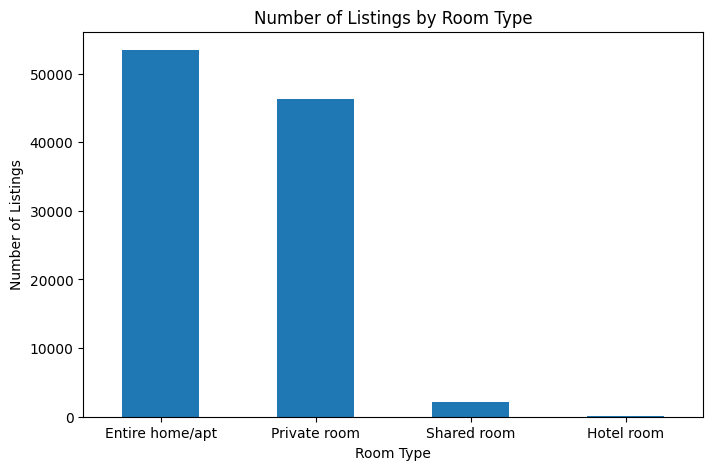

In [ ]:
#Exploratory Data Analysis (EDA)

 #Distribution of room types
 
room_counts = df['room_type'].value_counts()
print(room_counts)

plt.figure(figsize=(8,5))
room_counts.plot(kind='bar')
plt.title('Number of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.show()

Entire Home or apartments are most common listing type, followed by Private room

neighbourhood_group
Queens           630.201485
Bronx            627.755011
Brooklyn         626.496373
Staten Island    623.990516
Manhattan        622.654338
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64


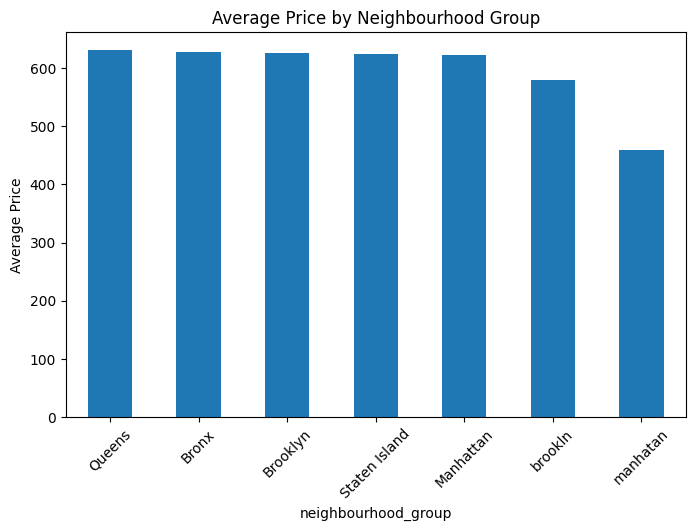

In [69]:
#Average price by neighbourhood group
avg_price =df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
print(avg_price)

plt.figure(figsize=(8,5))
avg_price.plot(kind='bar')
plt.title('Average Price by Neighbourhood Group')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

neighbourhood_group
Manhattan        43557
Brooklyn         41630
Queens           13197
Bronx             2694
Staten Island      949
brookln              1
manhatan             1
Name: count, dtype: int64


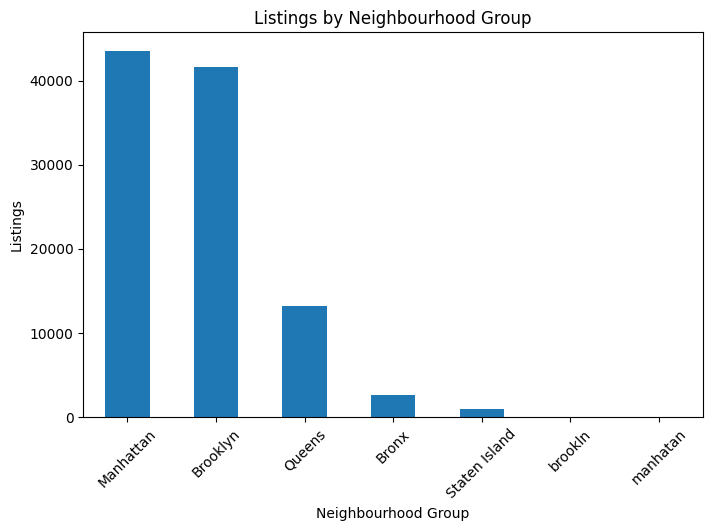

In [76]:
#Number of listings by neighbourhood group
neighbourhood_counts=df['neighbourhood_group'].value_counts()
print(neighbourhood_counts)

plt.figure(figsize=(8,5))
neighbourhood_counts.plot(kind='bar')
plt.title('Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Listings')
plt.xticks(rotation=45)
plt.show()

In [78]:
#Average Price by Room Type
room_price = df.groupby('room_type')['price'].mean().sort_values(ascending=False)
print(room_price)

room_type
Hotel room         666.391304
Shared room        634.788949
Entire home/apt    625.236969
Private room       624.933486
Name: price, dtype: float64


In [81]:
#Top 10 hosts
top_hosts = df['host_name'].value_counts().head(10)
print(top_hosts) 


host_name
Michael         878
David           761
John            577
Alex            543
Sonder (NYC)    516
Daniel          470
Karen           437
Sarah           428
Maria           421
Unknown         404
Name: count, dtype: int64


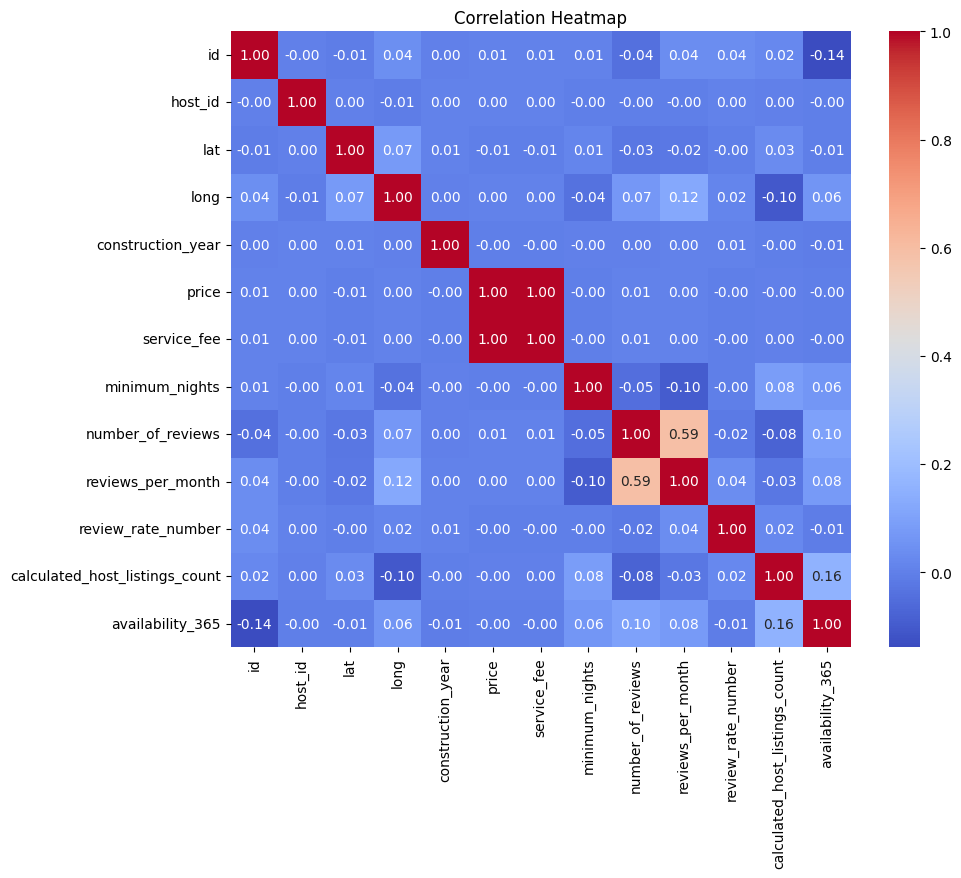

In [ ]:
#Correlation between numeric variables
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


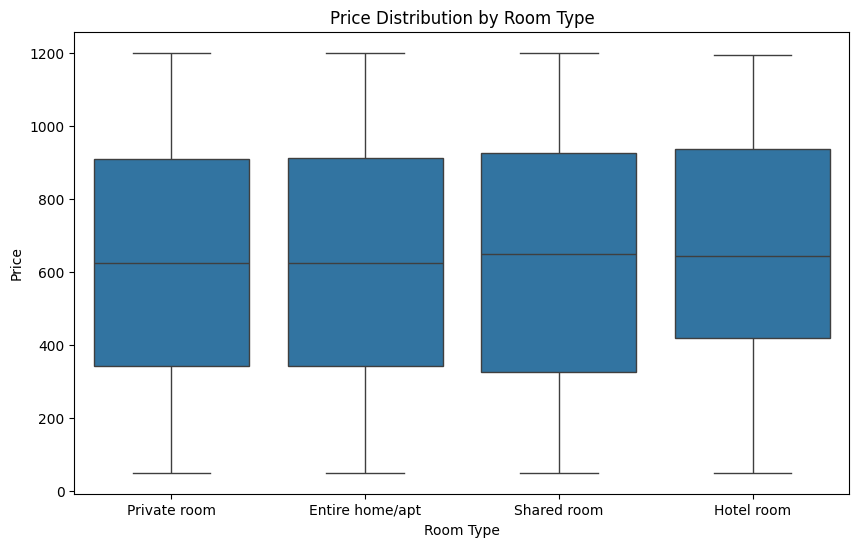

In [83]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='room_type', y='price')

plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price')

plt.show()

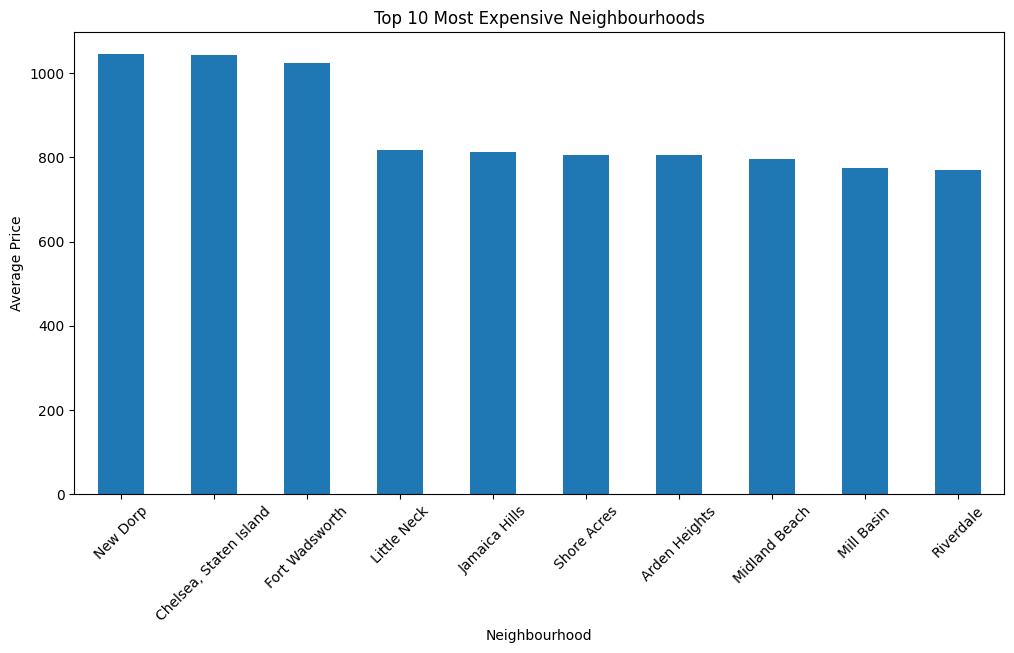

In [84]:
top_neighbourhoods = (
    df.groupby('neighbourhood')['price']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_neighbourhoods.plot(kind='bar')

plt.title('Top 10 Most Expensive Neighbourhoods')
plt.xlabel('Neighbourhood')
plt.ylabel('Average Price')

plt.xticks(rotation=45)

plt.show()

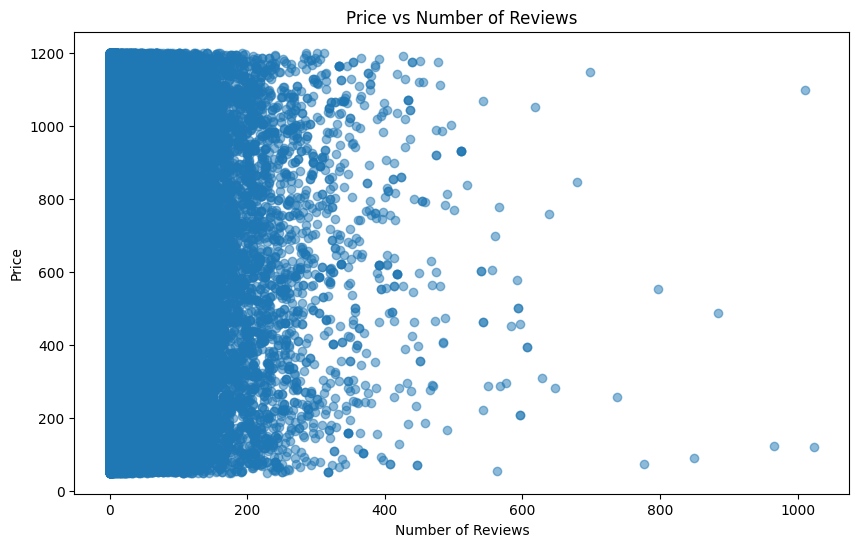

In [86]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['number_of_reviews'],
    df['price'],
    alpha=0.5
)

plt.title('Price vs Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')

plt.show()

# Key Insights

1. **Room Type Distribution:** Entire homes/apartments account for the largest share of Airbnb listings, indicating that travelers generally prefer complete private accommodations over shared spaces.

* **Neighbourhood Analysis:** Airbnb listings are concentrated in a few neighbourhood groups, suggesting that certain areas are significantly more popular among hosts and guests.

* **Pricing Trends:** Listing prices vary considerably across neighbourhoods. Premium locations have noticeably higher average prices, highlighting the impact of location on accommodation cost.

* **Room Type vs. Price:** Entire homes/apartments have the highest average prices, while shared rooms are the most affordable accommodation option.

* **Price Distribution:** The distribution of listing prices is right-skewed, meaning that most Airbnb properties are moderately priced, while a relatively small number of luxury listings have exceptionally high prices.

* **Host Activity:** Most hosts manage only a few listings, whereas a small number of hosts own multiple properties, indicating the presence of professional or commercial hosts.

* **Correlation Analysis:** The numerical variables in the dataset generally show weak to moderate correlations, suggesting that multiple factors influence Airbnb pricing rather than a single dominant feature.


#Conclusion

This analysis explored Airbnb listings by cleaning the dataset, handling missing values, correcting data types, and performing exploratory data analysis. The findings show that listing prices vary significantly by room type and neighbourhood. Entire homes/apartments command higher average prices, while certain neighbourhoods consistently have premium pricing. The analysis also highlights that a small number of hosts manage multiple properties. These insights can help hosts understand market trends and assist travelers in making informed booking decision.


